In [1]:
pip install pandas numpy scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

seed = 9001
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version:", tf.__version__)

2026-04-07 16:06:27.854915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775577988.105162      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775577988.178291      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775577988.798377      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775577988.798437      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775577988.798442      17 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [3]:
INPUT_PATH_OLD = "/kaggle/input/datasets/thuhiuhong/lstm-new-train-test-val"

X_train_old = np.load(os.path.join(INPUT_PATH_OLD, "X_train.npy"))
X_val_old   = np.load(os.path.join(INPUT_PATH_OLD, "X_val.npy"))
X_test_old  = np.load(os.path.join(INPUT_PATH_OLD, "X_test.npy"))

y_train_old = np.load(os.path.join(INPUT_PATH_OLD, "y_train.npy"))
y_val_old   = np.load(os.path.join(INPUT_PATH_OLD, "y_val.npy"))
y_test_old  = np.load(os.path.join(INPUT_PATH_OLD, "y_test.npy"))

In [4]:
X_train_old = X_train_old.astype(np.float32)
X_val_old   = X_val_old.astype(np.float32)
X_test_old  = X_test_old.astype(np.float32)

y_train_old = y_train_old.astype(np.float32).reshape(-1)
y_val_old   = y_val_old.astype(np.float32).reshape(-1)
y_test_old  = y_test_old.astype(np.float32).reshape(-1)

print("X_train_old:", X_train_old.shape, X_train_old.dtype)
print("X_val_old:", X_val_old.shape, X_val_old.dtype)
print("X_test_old:", X_test_old.shape, X_test_old.dtype)

print("y_train_old:", y_train_old.shape, y_train_old.dtype)
print("y_val_old:", y_val_old.shape, y_val_old.dtype)
print("y_test_old:", y_test_old.shape, y_test_old.dtype)

assert X_train_old.ndim == 3
assert X_val_old.ndim == 3
assert X_test_old.ndim == 3

assert len(X_train_old) == len(y_train_old)
assert len(X_val_old) == len(y_val_old)
assert len(X_test_old) == len(y_test_old)

print("timesteps =", X_train_old.shape[1])
print("n_features =", X_train_old.shape[2])

X_train_old: (145772, 10, 133) float32
X_val_old: (36597, 10, 133) float32
X_test_old: (45552, 10, 133) float32
y_train_old: (145772,) float32
y_val_old: (36597,) float32
y_test_old: (45552,) float32
timesteps = 10
n_features = 133


In [5]:
classes = np.unique(y_train_old)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_old
)

class_weights_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights:", class_weights_dict)

Class weights: {0: 0.5407133742841034, 1: 6.64048833819242}


In [6]:
BEST_UNITS = 16
BEST_DROPOUT = 0.3
BEST_BATCH = 512

FREEZE_EPOCHS = 5
FINETUNE_EPOCHS = 30

print("BEST_UNITS =", BEST_UNITS)
print("BEST_DROPOUT =", BEST_DROPOUT)
print("BEST_BATCH =", BEST_BATCH)
print("FREEZE_EPOCHS =", FREEZE_EPOCHS)
print("FINETUNE_EPOCHS =", FINETUNE_EPOCHS)

BEST_UNITS = 16
BEST_DROPOUT = 0.3
BEST_BATCH = 512
FREEZE_EPOCHS = 5
FINETUNE_EPOCHS = 30


In [7]:
def build_encoder(n_lstm_units, dropout_rate, input_shape):
    inputs = Input(shape=input_shape, name='encoder_input')

    x = Bidirectional(
        LSTM(n_lstm_units, return_sequences=True),
        name='bilstm_1'
    )(inputs)
    x = Dropout(dropout_rate, name='dropout_1')(x)
    x = BatchNormalization(name='bn_1')(x)

    x = Bidirectional(
        LSTM(max(n_lstm_units // 2, 8), return_sequences=False),
        name='bilstm_2'
    )(x)
    x = Dropout(dropout_rate, name='dropout_2')(x)
    x = BatchNormalization(name='bn_2')(x)

    shared = Dense(16, activation='relu', name='shared_dense')(x)

    encoder = Model(inputs, shared, name='encoder')
    return encoder

In [8]:
def build_sepsis_model_from_encoder(n_lstm_units, dropout_rate, input_shape):
    encoder = build_encoder(n_lstm_units, dropout_rate, input_shape)

    inputs = encoder.input
    shared = encoder.output

    x = Dropout(0.2, name='head_dropout')(shared)
    sepsis_out = Dense(1, activation='sigmoid', name='sepsis')(x)

    model = Model(inputs, sepsis_out, name='sepsis_finetune_model')
    return model, encoder

In [9]:
PRETRAINED_ENCODER_PATH = "/kaggle/input/datasets/thuhiuhong/pretrain-lstm/encoder_pretrained_vital.weights.h5"

sepsis_model, encoder_ft = build_sepsis_model_from_encoder(
    n_lstm_units=BEST_UNITS,
    dropout_rate=BEST_DROPOUT,
    input_shape=(X_train_old.shape[1], X_train_old.shape[2])
)

encoder_ft.load_weights(PRETRAINED_ENCODER_PATH)

print("✅ Đã load pretrained encoder weights")
sepsis_model.summary()

✅ Đã load pretrained encoder weights


2026-04-07 16:07:17.085126: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sepsis_finetune_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 10, 133)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 10, 32)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 16)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense (Dense)            │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sepsis (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,209 (86.75 KB)

 Non-trainable params: 96 (384.00 B)

In [10]:
for layer in encoder_ft.layers:
    layer.trainable = False

sepsis_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(curve='ROC', name='auroc'),
        tf.keras.metrics.AUC(curve='PR', name='auprc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

print("=== Stage A: Freeze encoder, train sepsis head ===")
history_stageA = sepsis_model.fit(
    X_train_old, y_train_old,
    validation_data=(X_val_old, y_val_old),
    epochs=FREEZE_EPOCHS,
    batch_size=BEST_BATCH,
    class_weight=class_weights_dict,
    verbose=1
)

=== Stage A: Freeze encoder, train sepsis head ===
Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - auprc: 0.0675 - auroc: 0.4568 - loss: 0.7895 - precision: 0.0695 - recall: 0.6346 - val_auprc: 0.0787 - val_auroc: 0.4696 - val_loss: 0.6980 - val_precision: 0.0704 - val_recall: 0.5750
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - auprc: 0.0833 - auroc: 0.5260 - loss: 0.7174 - precision: 0.0817 - recall: 0.5282 - val_auprc: 0.1174 - val_auroc: 0.6108 - val_loss: 0.6663 - val_precision: 0.1039 - val_recall: 0.5141
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - auprc: 0.1026 - auroc: 0.5619 - loss: 0.6954 - precision: 0.0901 - recall: 0.5345 - val_auprc: 0.1252 - val_auroc: 0.6353 - val_loss: 0.6560 - val_precision: 0.1098 - val_recall: 0.5063
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - auprc: 0.1108 - auroc: 0.5816 - loss: 0.6850 - precision: 0.0947 - recall: 0.5343 - val_auprc: 0.1288 - val_auroc: 0.6439 - val_loss: 0.6491 - val_precision: 0.1136 - val_rec

In [11]:
for layer in encoder_ft.layers:
    layer.trainable = True

sepsis_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(curve='ROC', name='auroc'),
        tf.keras.metrics.AUC(curve='PR', name='auprc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

early_stopping = EarlyStopping(
    monitor='val_auprc',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auprc',
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/kaggle/working/best_sepsis_finetune_model.keras',
    monitor='val_auprc',
    mode='max',
    save_best_only=True,
    verbose=1
)

print("=== Stage B: Unfreeze encoder, fine-tune whole model ===")
history_stageB = sepsis_model.fit(
    X_train_old, y_train_old,
    validation_data=(X_val_old, y_val_old),
    epochs=FINETUNE_EPOCHS,
    batch_size=BEST_BATCH,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

=== Stage B: Unfreeze encoder, fine-tune whole model ===
Epoch 1/30
283/285 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - auprc: 0.1677 - auroc: 0.6725 - loss: 0.6440 - precision: 0.1236 - recall: 0.5969
Epoch 1: val_auprc improved from -inf to 0.27595, saving model to /kaggle/working/best_sepsis_finetune_model.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - auprc: 0.1681 - auroc: 0.6729 - loss: 0.6438 - precision: 0.1238 - recall: 0.5972 - val_auprc: 0.2759 - val_auroc: 0.7970 - val_loss: 0.6061 - val_precision: 0.1865 - val_recall: 0.7032 - learning_rate: 1.0000e-04
Epoch 2/30
283/285 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - auprc: 0.2712 - auroc: 0.7846 - loss: 0.5651 - precision: 0.1955 - recall: 0.6597
Epoch 2: val_auprc improved from 0.27595 to 0.29504, saving model to /kaggle/working/best_sepsis_finetune_model.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - auprc: 0.2713 - auroc: 0.7847 - loss: 0.5650 - precision: 0.1956 - recall: 0.6597 - val_auprc: 0.2950 - val_auroc: 0.8160 - val_loss:

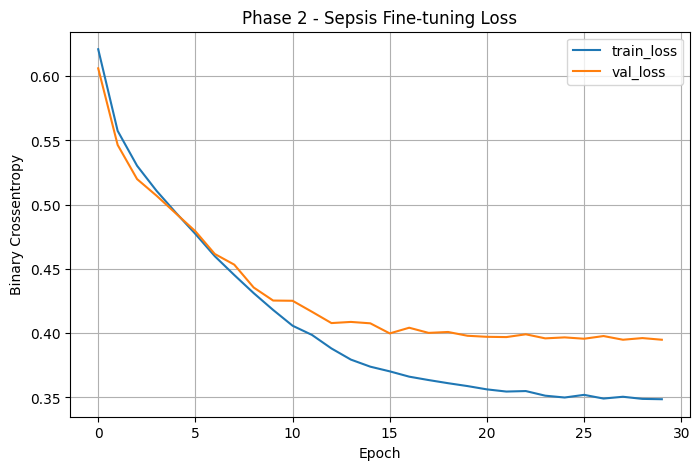

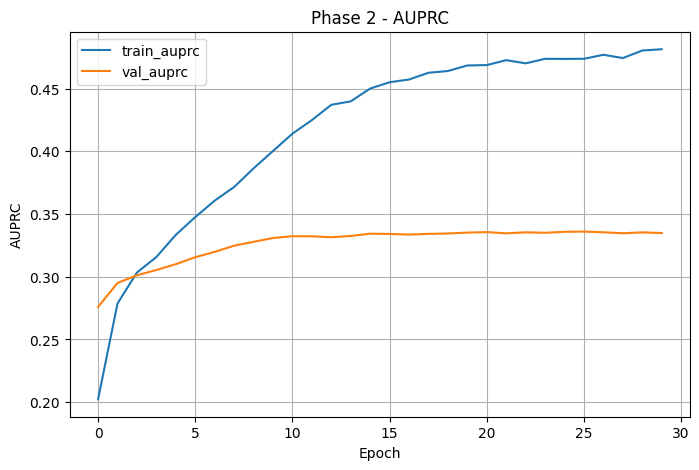

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history_stageB.history['loss'], label='train_loss')
plt.plot(history_stageB.history['val_loss'], label='val_loss')
plt.title('Phase 2 - Sepsis Fine-tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_stageB.history['auprc'], label='train_auprc')
plt.plot(history_stageB.history['val_auprc'], label='val_auprc')
plt.title('Phase 2 - AUPRC')
plt.xlabel('Epoch')
plt.ylabel('AUPRC')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
val_prob = sepsis_model.predict(X_val_old, batch_size=BEST_BATCH, verbose=0).ravel()
test_prob = sepsis_model.predict(X_test_old, batch_size=BEST_BATCH, verbose=0).ravel()

print("val_prob shape:", val_prob.shape)
print("test_prob shape:", test_prob.shape)

val_prob shape: (36597,)
test_prob shape: (45552,)


In [14]:
val_auroc = roc_auc_score(y_val_old, val_prob)
val_auprc = average_precision_score(y_val_old, val_prob)

test_auroc = roc_auc_score(y_test_old, test_prob)
test_auprc = average_precision_score(y_test_old, test_prob)

print("Validation AUROC:", round(val_auroc, 4))
print("Validation AUPRC:", round(val_auprc, 4))
print("Test AUROC:", round(test_auroc, 4))
print("Test AUPRC:", round(test_auprc, 4))

Validation AUROC: 0.8335
Validation AUPRC: 0.3362
Test AUROC: 0.8549
Test AUPRC: 0.3568


In [15]:
rows = []
for th in np.arange(0.05, 0.96, 0.01):
    val_pred = (val_prob >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_old, val_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_j = sensitivity + specificity - 1

    rows.append({
        "threshold": round(th, 2),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "youden_j": youden_j
    })

df_th = pd.DataFrame(rows)

candidate = df_th[df_th["sensitivity"] >= 0.80].copy()
best = candidate.sort_values("specificity", ascending=False).iloc[0]

print(best)

threshold      0.210000
sensitivity    0.800931
specificity    0.718288
youden_j       0.519219
Name: 16, dtype: float64


In [16]:
best_threshold = float(best["threshold"])

test_pred = (test_prob >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_old, test_pred).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
precision = precision_score(y_test_old, test_pred, zero_division=0)
recall = recall_score(y_test_old, test_pred, zero_division=0)
f1 = f1_score(y_test_old, test_pred, zero_division=0)
acc = accuracy_score(y_test_old, test_pred)
youden_j = sensitivity + specificity - 1

auroc = roc_auc_score(y_test_old, test_prob)
auprc = average_precision_score(y_test_old, test_prob)

print(f"=== TEST RESULT WITH THRESHOLD = {best_threshold:.2f} ===")
print(f"AUROC:       {auroc:.4f}")
print(f"AUPRC:       {auprc:.4f}")
print(f"Accuracy:    {acc:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-score:    {f1:.4f}")
print(f"Youden's J:  {youden_j:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_old, test_pred))

print("\nClassification Report:")
print(classification_report(y_test_old, test_pred, digits=4))

=== TEST RESULT WITH THRESHOLD = 0.21 ===
AUROC:       0.8549
AUPRC:       0.3568
Accuracy:    0.7306
Sensitivity: 0.8339
Specificity: 0.7227
Precision:   0.1859
Recall:      0.8339
F1-score:    0.3041
Youden's J:  0.5567

Confusion Matrix:
[[30599 11738]
 [  534  2681]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9828    0.7227    0.8330     42337
         1.0     0.1859    0.8339    0.3041      3215

    accuracy                         0.7306     45552
   macro avg     0.5844    0.7783    0.5685     45552
weighted avg     0.9266    0.7306    0.7956     45552

